In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import linregress

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = BASE_DIR / "data" / "processed"
REPORT_PATH = BASE_DIR / "reports" / "figures"

REPORT_PATH.mkdir(parents=True, exist_ok=True)

fund_master = pd.read_csv(DATA_PATH/"01_fund_master_cleaned.csv")
nav = pd.read_csv(DATA_PATH/"02_nav_history_cleaned.csv")
aum = pd.read_csv(DATA_PATH/"03_aum_by_fund_house_cleaned.csv")
sip = pd.read_csv(DATA_PATH/"04_monthly_sip_inflows_cleaned.csv")
category = pd.read_csv(DATA_PATH/"05_category_inflows_cleaned.csv")
folio = pd.read_csv(DATA_PATH/"06_industry_folio_count_cleaned.csv")
performance = pd.read_csv(DATA_PATH/"07_scheme_performance_cleaned.csv")
investor = pd.read_csv(DATA_PATH/"08_investor_transactions_cleaned.csv")
holding = pd.read_csv(DATA_PATH/"09_portfolio_holdings_cleaned.csv")
benchmark = pd.read_csv(DATA_PATH/"10_benchmark_indices_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav["daily_return"] = (nav.groupby("amfi_code")["nav"].pct_change())
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


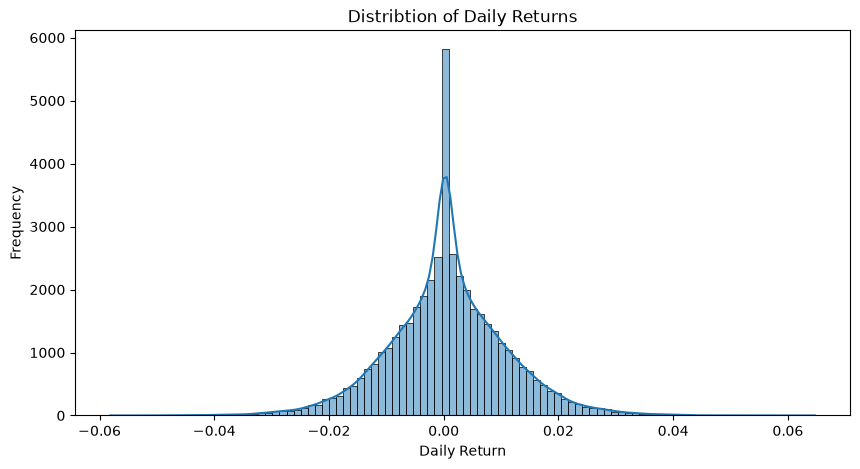

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot( nav["daily_return"].dropna(), bins=100, kde=True)

plt.title("Distribtion of Daily Returns")
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.show()

In [5]:
print(nav["daily_return"].describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [6]:
nav.to_csv(
    "../data/processed/nav_daily_returns.csv",
    index=False
)

print("Daily Returns Saved Successfully")

Daily Returns Saved Successfully


In [7]:
fund = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

fund = fund[["amfi_code", "scheme_name"]]

In [8]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav)  ** (1 / years)) - 1

In [9]:
results = []

for code,group in nav.groupby("amfi_code"):
    group = group.sort_values("date")
    latest = group.iloc[-1]
    latest_date = latest["date"]
    latest_nav = latest["nav"]
    row = {"amfi_code": code}

    for years in [1, 3, 5]:
        start_date = latest_date - pd.DateOffset(years=years)
        previous = group[group["date"] <= start_date]

        if len(previous) > 0:
            start_nav = previous.iloc[-1]["nav"]
            row[f"CAGR_{years}Y"] = calculate_cagr(start_nav, latest_nav, years)

        else:
            row[f"CAGR_{years}Y"] = np.nan

results.append(row)

In [10]:
cagr = pd.DataFrame(results)

cagr = cagr.merge( fund, on = "amfi_code", how="left")

cagr.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name
0,149324,0.651387,0.270004,NaN,DSP Small Cap Fund - Regular - Growth


In [11]:
for col in ["CAGR_1Y", "CAGR_3Y", "CAGR_5Y"]:

    cagr[col] = cagr[col] * 100

cagr.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name
0,149324,65.138719,27.000427,NaN,DSP Small Cap Fund - Regular - Growth


In [12]:
cagr.to_csv(
    "../data/processed/fund_cagr.csv",
    index=False
)

print("CAGR Saved Successfully")

CAGR Saved Successfully


In [13]:
risk_free_rate = 0.065

trading_days = 252

In [14]:
sharpe = (
    nav.groupby("amfi_code")["daily_return"]
    .agg(["mean", "std"])
    .reset_index()
)

sharpe["Sharpe_Ratio"] = (
    ((sharpe["mean"] * trading_days) - risk_free_rate)
    /
    (sharpe["std"] * np.sqrt(trading_days))
)

In [15]:
sharpe = sharpe.merge(
    fund,
    on="amfi_code",
    how="left"
)

sharpe = sharpe.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe.head()

,amfi_code,mean,std,Sharpe_Ratio,scheme_name
34,148567,0.001074,0.008941,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.001082,0.010008,1.306744,Kotak Flexicap Fund - Regular - Growth
36,148569,0.001124,0.011134,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,0.000917,0.008656,1.208267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,0.001161,0.012152,1.180101,ICICI Pru Midcap Fund - Regular - Growth


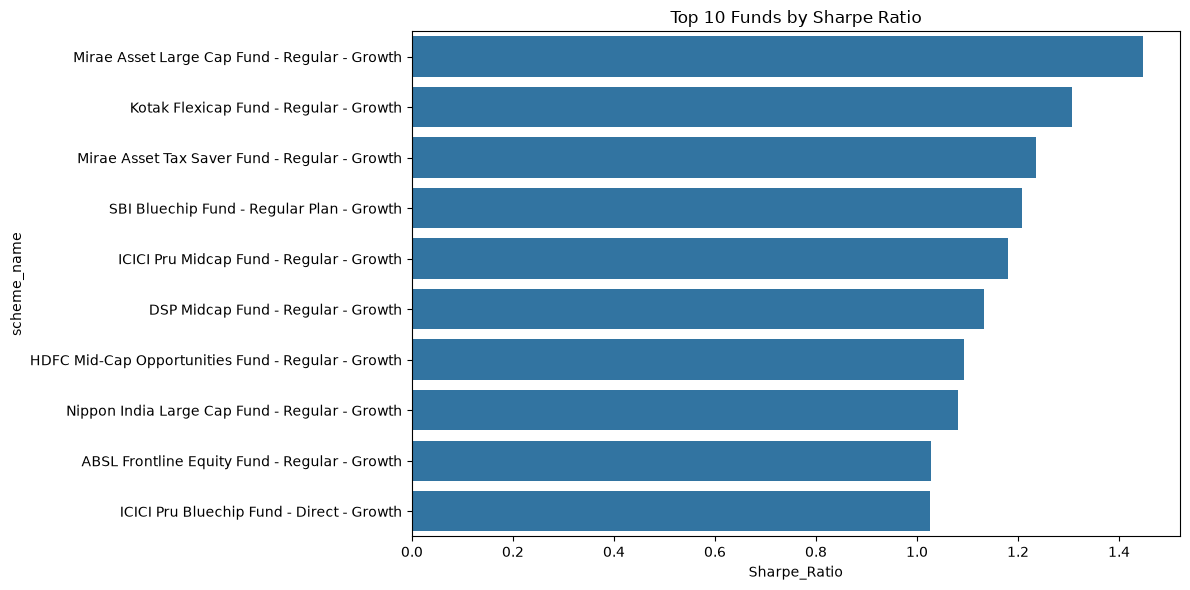

In [16]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sharpe.head(10),
    x="Sharpe_Ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.tight_layout()

plt.show()

In [17]:
sharpe.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio Saved Successfully")

Sharpe Ratio Saved Successfully


In [18]:
risk_free_rate = 0.065
trading_days = 252

sortino_results = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        continue

    mean_return = returns.mean()

    downside_returns = returns[returns < 0]

    if len(downside_returns) == 0:
        downside_std = np.nan
    else:
        downside_std = downside_returns.std()

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = (
            ((mean_return * trading_days) - risk_free_rate)
            /
            (downside_std * np.sqrt(trading_days))
        )

    sortino_results.append({
        "amfi_code": code,
        "Sortino_Ratio": sortino
    })

In [19]:
sortino = pd.DataFrame(sortino_results)

sortino = sortino.merge(
    fund,
    on="amfi_code",
    how="left"
)

sortino = sortino.sort_values(
    by="Sortino_Ratio",
    ascending=False
)

sortino.head()

,amfi_code,Sortino_Ratio,scheme_name
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth


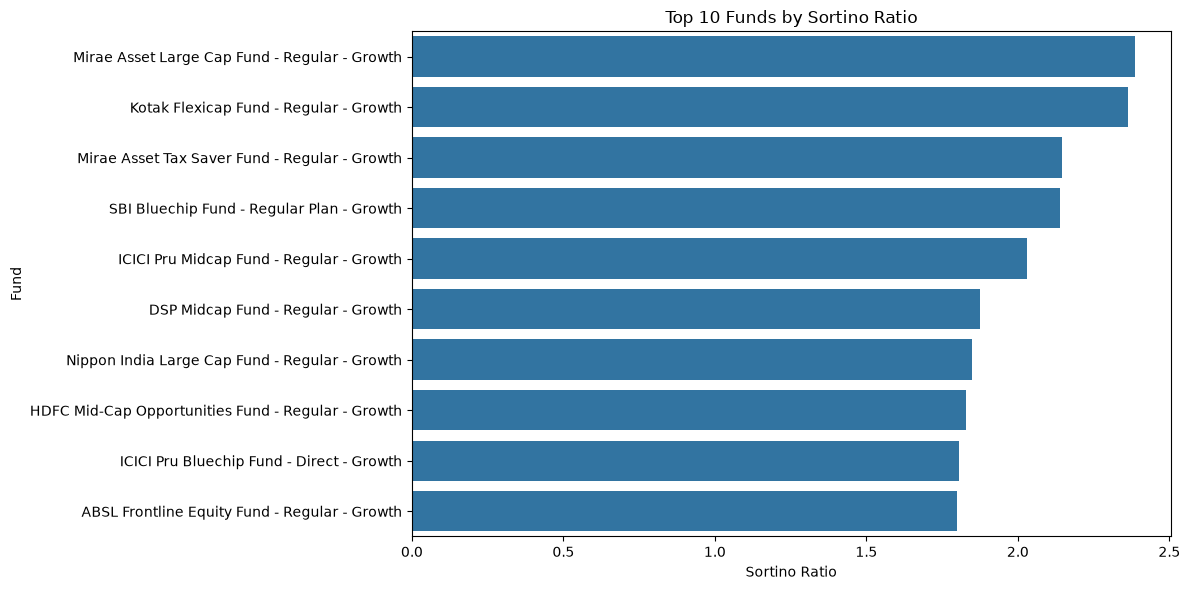

In [20]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sortino.head(10),
    x="Sortino_Ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("Sortino Ratio")
plt.ylabel("Fund")

plt.tight_layout()

plt.savefig(
    REPORT_PATH / "03_sortino_ratio.png",
    dpi=300
)

plt.show()

In [21]:
plt.savefig(
    REPORT_PATH / "03_sortino_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [22]:
print(benchmark["index_name"].unique())

<StringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str


In [23]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,NIFTY100,17778.24,NaN
3451,2022-01-04,NIFTY100,17537.52,-0.013540
3452,2022-01-05,NIFTY100,17607.73,0.004003
3453,2022-01-06,NIFTY100,17556.05,-0.002935
3454,2022-01-07,NIFTY100,17664.02,0.006150


In [24]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [25]:
merged_data = nav.merge(
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

merged_data.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003
3,100016,2022-01-06,515.7880,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.006150


In [26]:
from scipy.stats import linregress

alpha_beta = []

for code in merged_data["amfi_code"].unique():

    fund_data = merged_data[
        merged_data["amfi_code"] == code
    ].dropna()

    if len(fund_data) < 30:
        continue

    result = linregress(
        fund_data["benchmark_return"],
        fund_data["daily_return"]
    )

    alpha_beta.append({

        "amfi_code": code,

        "Alpha": result.intercept * 252,

        "Beta": result.slope

    })

In [27]:
alpha_beta = pd.DataFrame(alpha_beta)

alpha_beta = alpha_beta.merge(

    fund_master[["amfi_code", "scheme_name"]],

    on="amfi_code",

    how="left"

)

alpha_beta = alpha_beta.sort_values(

    by="Alpha",

    ascending=False

)

alpha_beta.head()

,amfi_code,Alpha,Beta,scheme_name
21,119598,0.303370,-0.023196,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.300579,0.011455,DSP Small Cap Fund - Regular - Growth
25,120505,0.292636,0.000549,ICICI Pru Midcap Fund - Regular - Growth
36,148569,0.282704,0.018134,Mirae Asset Tax Saver Fund - Regular - Growth
30,120843,0.273305,-0.022830,Kotak Flexicap Fund - Regular - Growth


In [28]:
alpha_beta.to_csv(

    DATA_PATH / "alpha_beta.csv",

    index=False

)

print("Alpha Beta CSV Saved Successfully")

Alpha Beta CSV Saved Successfully


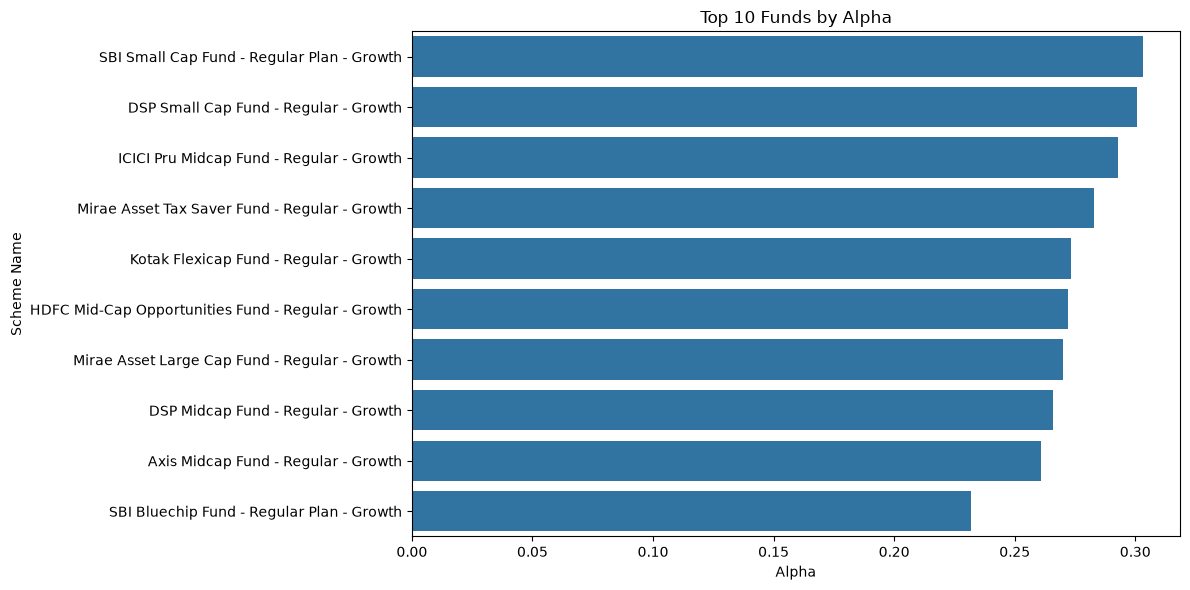

In [29]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=alpha_beta.head(10),

    x="Alpha",

    y="scheme_name"

)

plt.title("Top 10 Funds by Alpha")

plt.xlabel("Alpha")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.savefig(

    REPORT_PATH / "04_alpha_chart.png",

    dpi=300

)

plt.show()

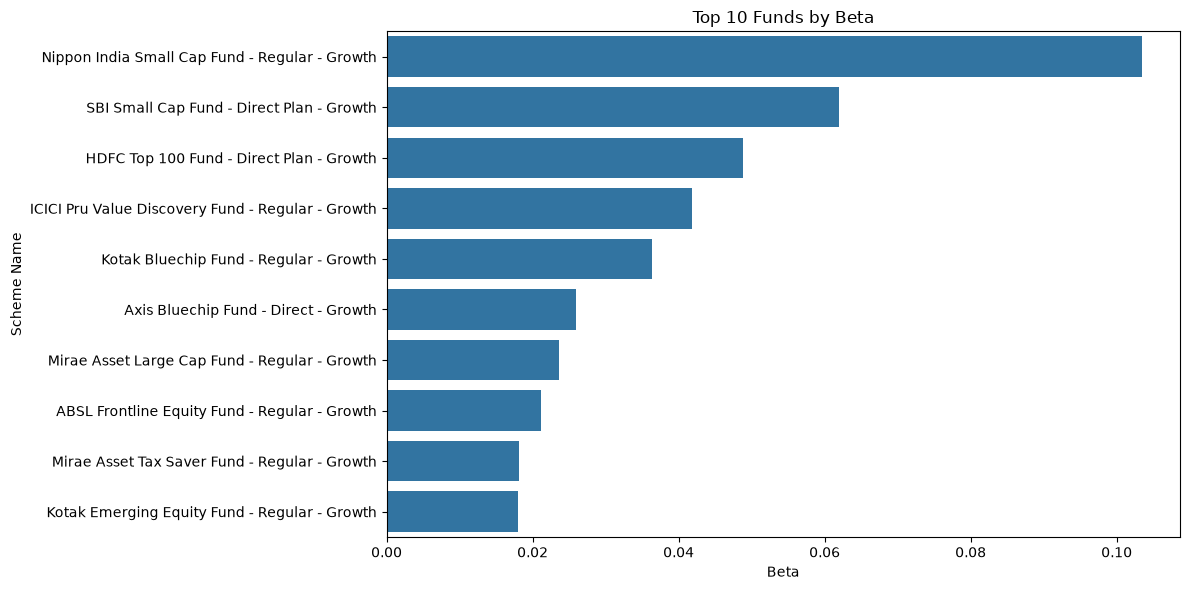

In [30]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=alpha_beta.sort_values(

        by="Beta",

        ascending=False

    ).head(10),

    x="Beta",

    y="scheme_name"

)

plt.title("Top 10 Funds by Beta")

plt.xlabel("Beta")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.savefig(

    REPORT_PATH / "05_beta_chart.png",

    dpi=300

)

plt.show()

In [31]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["running_max"] = (
    nav.groupby("amfi_code")["nav"]
    .cummax()
)

nav.head()

,amfi_code,date,nav,daily_return,running_max
0,100016,2022-01-03,520.4608,NaN,520.4608
1,100016,2022-01-04,515.0971,-0.010306,520.4608
2,100016,2022-01-05,521.7239,0.012865,521.7239
3,100016,2022-01-06,515.7880,-0.011377,521.7239
4,100016,2022-01-07,515.1639,-0.001210,521.7239


In [32]:
nav["drawdown"] = (

    nav["nav"]

    /

    nav["running_max"]

) - 1

nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
0,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
1,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
2,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
3,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


In [33]:
max_drawdown = (

    nav.groupby("amfi_code")["drawdown"]

    .min()

    .reset_index()

)

max_drawdown.rename(

    columns={

        "drawdown":"Maximum_Drawdown"

    },

    inplace=True

)

max_drawdown.head()

,amfi_code,Maximum_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [34]:
max_drawdown = max_drawdown.merge(

    fund_master[

        ["amfi_code","scheme_name"]

    ],

    on="amfi_code",

    how="left"

)

max_drawdown = max_drawdown.sort_values(

    by="Maximum_Drawdown"

)

max_drawdown.head()

,amfi_code,Maximum_Drawdown,scheme_name
22,119599,-0.525742,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.516778,Axis Small Cap Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth
39,149324,-0.311719,DSP Small Cap Fund - Regular - Growth
21,119598,-0.287060,SBI Small Cap Fund - Regular Plan - Growth


In [35]:
max_drawdown.to_csv(

    DATA_PATH / "maximum_drawdown.csv",

    index=False

)

print("Maximum Drawdown Saved Successfully")

Maximum Drawdown Saved Successfully


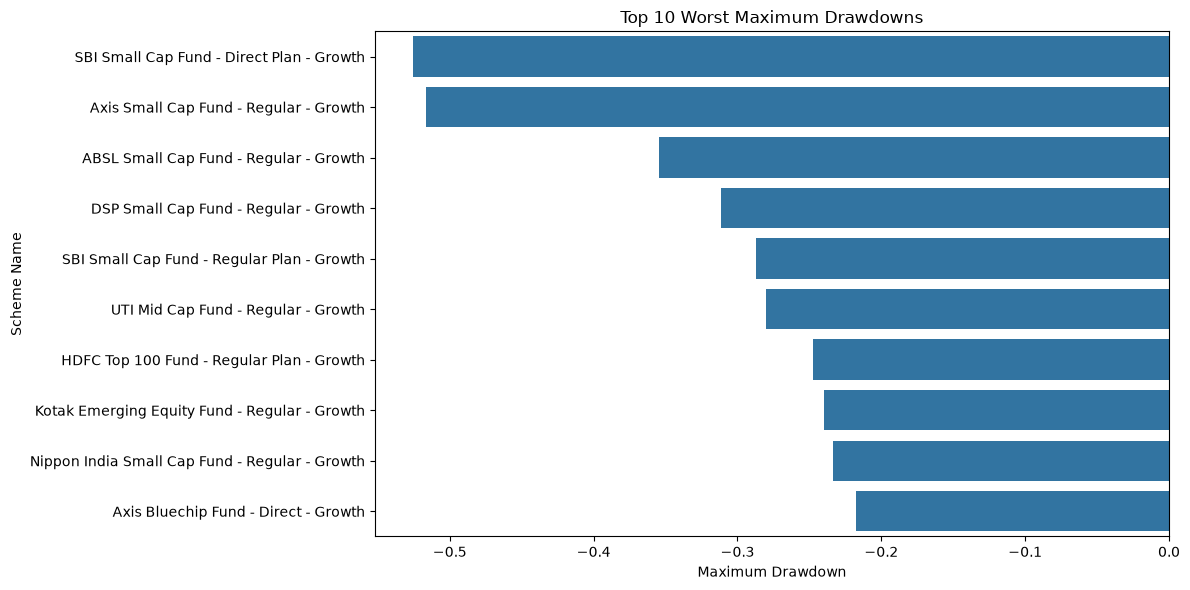

In [36]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=max_drawdown.head(10),

    x="Maximum_Drawdown",

    y="scheme_name"

)

plt.title("Top 10 Worst Maximum Drawdowns")

plt.xlabel("Maximum Drawdown")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.savefig(

    REPORT_PATH / "06_maximum_drawdown.png",

    dpi=300

)

plt.show()

In [37]:
scorecard = performance[
    [
        "amfi_code",
        "scheme_name",
        "return_3yr_pct",
        "expense_ratio_pct"
    ]
].copy()

scorecard = scorecard.merge(

    sharpe[
        ["amfi_code","Sharpe_Ratio"]
    ],

    on="amfi_code"

)

scorecard = scorecard.merge(

    alpha_beta[
        ["amfi_code","Alpha"]
    ],

    on="amfi_code"

)

scorecard = scorecard.merge(

    max_drawdown[
        ["amfi_code","Maximum_Drawdown"]
    ],

    on="amfi_code"

)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown
0,101206,ABSL Frontline Equity Fund - Regular - Growth,13.78,1.60,1.027213,0.213998,-0.112916
1,101208,ABSL Liquid Fund - Regular - Growth,5.14,0.79,-0.815567,0.060861,-0.001622
2,101207,ABSL Small Cap Fund - Regular - Growth,22.38,1.53,0.162661,0.108971,-0.354469
3,119093,Axis Bluechip Fund - Direct - Growth,12.14,0.75,0.129614,0.082328,-0.217514
4,119092,Axis Bluechip Fund - Regular - Growth,11.84,1.64,0.030785,0.068995,-0.144016


In [38]:
scorecard["Return_Rank"] = (
    scorecard["return_3yr_pct"]
    .rank(ascending=False)
)

scorecard["Sharpe_Rank"] = (
    scorecard["Sharpe_Ratio"]
    .rank(ascending=False)
)

scorecard["Alpha_Rank"] = (
    scorecard["Alpha"]
    .rank(ascending=False)
)

scorecard["Expense_Rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["Drawdown_Rank"] = (
    scorecard["Maximum_Drawdown"]
    .rank(ascending=False)
)

In [39]:
scorecard["Fund_Score"] = (

      scorecard["Return_Rank"] * 0.30

    + scorecard["Sharpe_Rank"] * 0.25

    + scorecard["Alpha_Rank"] * 0.20

    + scorecard["Expense_Rank"] * 0.15

    + scorecard["Drawdown_Rank"] * 0.10

)

In [40]:
max_score = scorecard["Fund_Score"].max()

scorecard["Fund_Score"] = (

    100 -

    (

        scorecard["Fund_Score"]

        /

        max_score

    ) * 100

).round(2)

In [41]:
scorecard = scorecard.sort_values(

    by="Fund_Score",

    ascending=False

)

scorecard.head(10)

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,Sharpe_Ratio,Alpha,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score
18,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,1.180101,0.292636,-0.181885,8.0,5.0,3.0,15.0,25.0,70.54
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,1.306744,0.273305,-0.129740,11.0,2.0,5.0,22.0,13.0,69.23
11,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.093699,0.271954,-0.162172,10.0,7.0,6.0,17.0,20.0,65.63
36,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060,1.0,14.0,1.0,21.0,36.0,64.81
25,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.46,1.448291,0.269838,-0.112657,17.0,1.0,7.0,23.0,8.0,63.99
8,149324,DSP Small Cap Fund - Regular - Growth,20.08,1.52,0.949796,0.300579,-0.311719,6.0,13.0,2.0,26.5,37.0,57.04
7,149323,DSP Midcap Fund - Regular - Growth,17.16,1.61,1.132122,0.265986,-0.172481,9.0,6.0,8.0,38.0,22.0,55.16
15,120504,ICICI Pru Bluechip Fund - Direct - Growth,14.41,0.80,1.026524,0.211948,-0.125883,20.0,10.0,13.0,12.0,12.0,53.85
5,119094,Axis Midcap Fund - Regular - Growth,15.18,1.38,0.998231,0.260767,-0.209609,15.0,11.0,9.0,17.0,28.0,52.86
26,148569,Mirae Asset Tax Saver Fund - Regular - Growth,13.58,1.60,1.234930,0.282704,-0.163967,23.0,3.0,4.0,36.5,21.0,47.55


In [42]:
scorecard.to_csv(

    DATA_PATH / "fund_scorecard.csv",

    index=False

)

print("Fund Scorecard Saved Successfully")

Fund Scorecard Saved Successfully


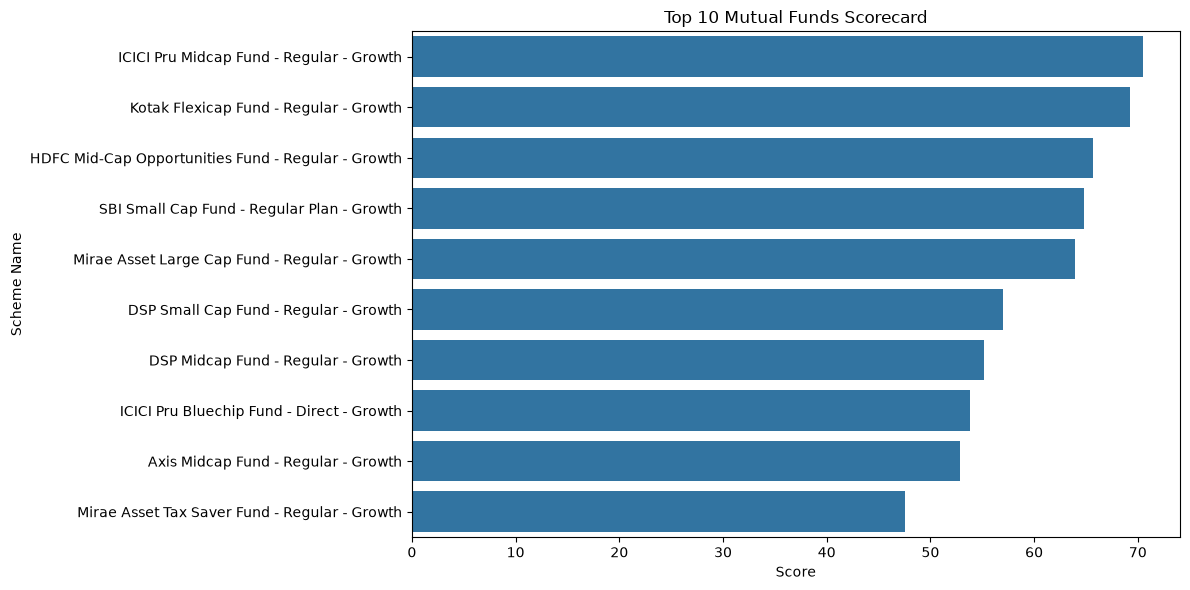

In [43]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=scorecard.head(10),

    x="Fund_Score",

    y="scheme_name"

)

plt.title("Top 10 Mutual Funds Scorecard")

plt.xlabel("Score")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.savefig(

    REPORT_PATH/"07_fund_scorecard.png",

    dpi=300

)

plt.show()

In [44]:
top5 = scorecard.head(5)

top5_codes = top5["amfi_code"].tolist()

top5_codes

[120505, 120843, 100033, 119598, 148567]

In [45]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark_plot = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

In [46]:
top5_nav = nav[
    nav["amfi_code"].isin(top5_codes)
].copy()

top5_nav = top5_nav.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

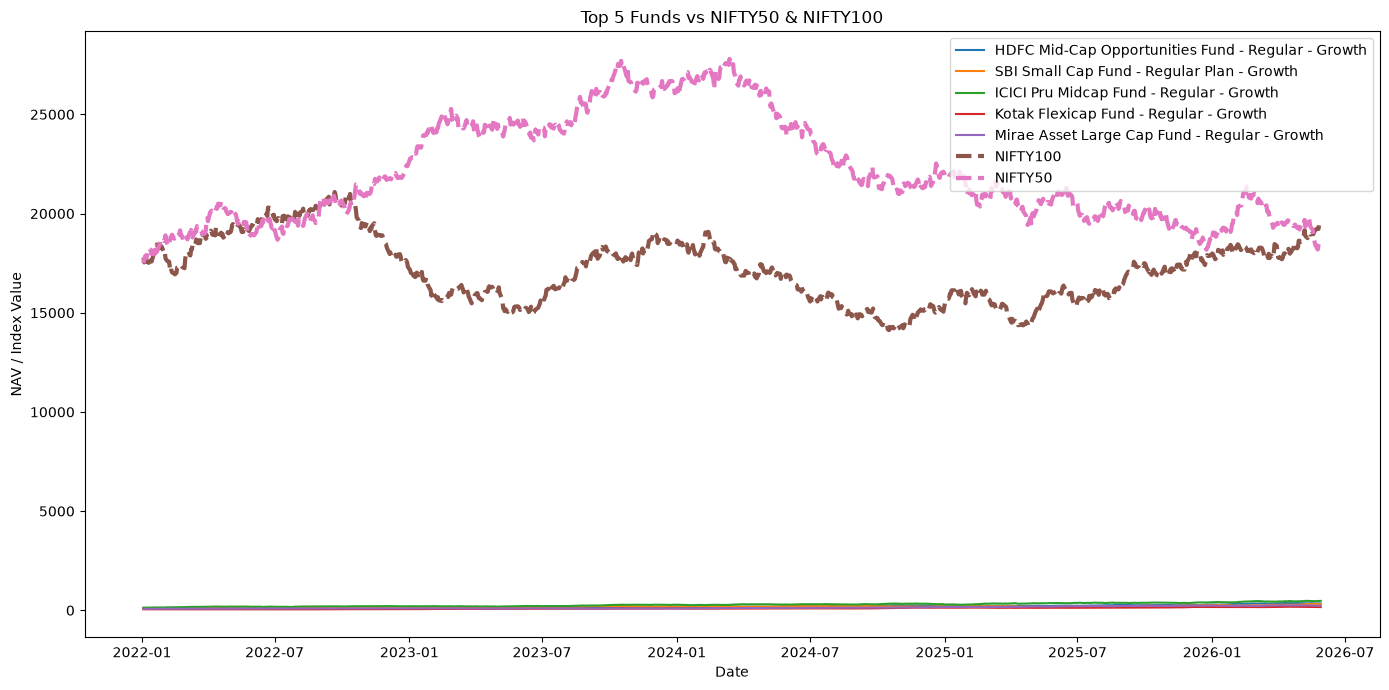

In [47]:
plt.figure(figsize=(14,7))

for scheme in top5_nav["scheme_name"].unique():

    data = top5_nav[
        top5_nav["scheme_name"] == scheme
    ]

    plt.plot(
        data["date"],
        data["nav"],
        label=scheme
    )

for index in benchmark_plot["index_name"].unique():

    data = benchmark_plot[
        benchmark_plot["index_name"] == index
    ]

    plt.plot(
        data["date"],
        data["close_value"],
        linewidth=3,
        linestyle="--",
        label=index
    )

plt.legend()

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100")

plt.xlabel("Date")

plt.ylabel("NAV / Index Value")

plt.tight_layout()

plt.savefig(
    REPORT_PATH/"08_benchmark_comparison.png",
    dpi=300
)

plt.show()

In [48]:
tracking_error = []

for code in top5_codes:

    fund = nav[
        nav["amfi_code"] == code
    ][
        ["date", "daily_return"]
    ]

    benchmark_return = benchmark_plot[
        benchmark_plot["index_name"] == "NIFTY100"
    ][
        ["date", "close_value"]
    ].copy()

    benchmark_return["benchmark_return"] = (
        benchmark_return["close_value"]
        .pct_change()
    )

    merged = fund.merge(

        benchmark_return[
            ["date", "benchmark_return"]
        ],

        on="date",

        how="inner"

    ).dropna()

    te = (

        merged["daily_return"]

        -

        merged["benchmark_return"]

    ).std() * np.sqrt(252)

    tracking_error.append({

        "amfi_code": code,

        "Tracking_Error": te

    })

In [49]:
tracking_error = pd.DataFrame(tracking_error)

tracking_error = tracking_error.merge(

    fund_master[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

tracking_error.to_csv(

    DATA_PATH/"tracking_error.csv",

    index=False

)

tracking_error

,amfi_code,Tracking_Error,scheme_name
0,120505,0.231968,ICICI Pru Midcap Fund - Regular - Growth
1,120843,0.206425,Kotak Flexicap Fund - Regular - Growth
2,100033,0.228699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,119598,0.283881,SBI Small Cap Fund - Regular Plan - Growth
4,148567,0.189664,Mirae Asset Large Cap Fund - Regular - Growth
